# Data Analysis of Survey Results - AI Detection and Generation of Jokes
## By: Mirabel Luo and Hayden Chang

# MIRABEL TODO: make sure you note the code dependencies needed!

In [1]:
# --- Standard Library Imports ---
import os
import json
import re
import time

# --- Data Processing ---
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- API & Environment Management ---
from dotenv import load_dotenv
from openai import OpenAI
from anthropic import Anthropic
import google.genai as genai

# Increase font_scale to 1.5 or 1.8 for much larger text
sns.set_context("notebook", font_scale=1.5)

## Data Preparation of API Keys

In [2]:
load_dotenv()

client_gpt = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
client_claude = Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
client_gemini = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

print("API Clients Initialized.")

API Clients Initialized.


In [5]:
def verify_api_connections():
    print("=== API Health Check ===")
    
    # Check OpenAI
    try:
        client_gpt.models.list()
        print("OpenAI: Connection active.")
    except Exception as e:
        print(f"OpenAI: Failed. {e}")
    """
    # Check Anthropic (Using the new 4-6 ID)
    try:
        client_claude.messages.create(
            model="claude-sonnet-4-6", 
            max_tokens=1,
            messages=[{"role": "user", "content": "Hi"}]
        )
        print("Anthropic: Connection active with claude-sonnet-4-6.")
    except Exception as e:
        print(f"Anthropic: Failed. {e}")
    """
    # Check Gemini (Using the 2.0 series)
    try:
        client_gemini.models.generate_content(
            model="gemini-2.5-pro", # Use Flash for a cheap health check
            contents="Hello"
        )
        print("Gemini: Connection active with gemini-2.5-pro.")
    except Exception as e:
        print(f"Gemini: Failed. {e}")

verify_api_connections()

=== API Health Check ===
OpenAI: Connection active.
Gemini: Connection active with gemini-2.5-pro.


In [37]:
def parse_response(text):
    """Extracts Rating and Source from the [Rating: X, Source: AI/Human] format."""
    match = re.search(r"\[Rating:\s*(\d+),\s*Source:\s*(AI|Human)\]", text, re.IGNORECASE)
    if match:
        return int(match.group(1)), match.group(2).capitalize()
    return None, None

import time

def call_model(model_name, prompt):
    model_name_lower = model_name.lower()
    
    # 2026 Free Tier limits are roughly 1 request every 6-12 seconds.
    # We add a sleep here to prevent the 429 error during your 72-request run.
    time.sleep(6) 

    try:
        if "gpt" in model_name_lower:
            resp = client_gpt.chat.completions.create(
                model="gpt-4o", 
                messages=[{"role": "user", "content": prompt}]
            )
            return resp.choices[0].message.content
            
        elif "claude" in model_name_lower:
            # As verified by your curl, use the 4.6 series
            resp = client_claude.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=150,
                messages=[{"role": "user", "content": prompt}]
            )
            return resp.content[0].text
            
        elif "gemini" in model_name_lower:
            # Switching from retired 2.0 to the current 2.5 series
            resp = client_gemini.models.generate_content(
                model="gemini-2.5-flash", 
                contents=prompt
            )
            return resp.text
            
    except Exception as e:
        if "429" in str(e):
            print("Rate limit hit! Sleeping for 30 seconds...")
            time.sleep(30)
            return call_model(model_name, prompt) # Simple recursive retry
        print(f"Error calling {model_name}: {e}")
        return ""

def call_model_batch(model_name, prompt):
    model_name_lower = model_name.lower()
    try:
        if "gpt" in model_name_lower:
            resp = client_gpt.chat.completions.create(
                model="gpt-4o", 
                temperature=0.8, # Higher temperature for variety across 30 trials
                messages=[{"role": "user", "content": prompt}]
            )
            return resp.choices[0].message.content
            
        elif "claude" in model_name_lower:
            resp = client_claude.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=2000, # Increased for 24 responses
                temperature=0.8,
                messages=[{"role": "user", "content": prompt}]
            )
            return resp.content[0].text
            
        elif "gemini" in model_name_lower:
            # The new SDK handles long outputs well by default
            resp = client_gemini.models.generate_content(
                model="gemini-2.5-flash", 
                config={'temperature': 0.8},
                contents=prompt
            )
            return resp.text
    except Exception as e:
        print(f"Error: {e}")
        return ""

def parse_batch_response(text):
    """Finds all occurrences of 'QX: [Rating: Y, Source: Z]' in the text."""
    # Matches: Q1: [Rating: 4, Source: Human]
    pattern = r"(Q\d+):\s*\[Rating:\s*(\d+),\s*Source:\s*(AI|Human)\]"
    matches = re.findall(pattern, text, re.IGNORECASE)
    
    parsed_results = {}
    for q_id, rating, source in matches:
        parsed_results[q_id] = {
            "rating": int(rating),
            "source": 4 if source.capitalize() == "Human" else 1
        }
    return parsed_results

In [43]:
import pandas as pd
import time
import json

def run_batch_experiment(model_name):
    # Load Stimuli
    with open('stimuli.json', 'r') as f:
        stimuli = json.load(f)
    
    # Construct the master prompt 
    joke_list = "\n".join([f"{item['id']}: {item['text']}" for item in stimuli])
    
    prompt = (
        f"You are a participant in a linguistic study on humor.\n\n"
        f"Below are 24 text items. For EACH item, do two things:\n"
        f"1. Rate the humor (1-5).\n"
        f"2. Identify if it is AI or Human (1 = Very AI, 4 = Very Human).\n\n"
        f"FORMAT YOUR ENTIRE RESPONSE LIKE THIS (one line per joke):\n"
        f"Q1: [Rating: X, Source: AI/Human]\n"
        f"Q2: [Rating: X, Source: AI/Human]\n"
        f"...and so on for all 24 items.\n\n"
        f"ITEMS:\n{joke_list}"
    )

    raw_data = []
    max_retries = 3 
    
    # The Trial Loop
    for trial_idx in range(30):
        print(f"Running Batch Trial {trial_idx + 1}/30 for {model_name}...")
        
        attempts = 0
        success = False
        
        while attempts < max_retries and not success:
            # The function now sees 'prompt' defined in the scope above
            raw_output = call_model_batch(model_name, prompt) 
            batch_results = parse_batch_response(raw_output)
            
            if len(batch_results) == 24:
                success = True
                for q_id, data in batch_results.items():
                    raw_data.append({
                        'Question_Number': int(q_id.replace('Q', '')),
                        'Trial_Index': trial_idx + 1,
                        'Model': model_name,
                        'Humor_Rating': data['rating'],
                        'Source_Detection': data['source']
                    })
            else:
                attempts += 1
                print(f"Attempt {attempts} failed. Retrying...")
                time.sleep(5)

        # Save progress
        pd.DataFrame(raw_data).to_csv(f'RAW_Data_{model_name}_Batch.csv', index=False)
        time.sleep(10)

    # Summary Generation
    df_raw = pd.DataFrame(raw_data)
    summary = df_raw.groupby('Question_Number').agg({
        'Humor_Rating': 'mean',
        'Source_Detection': 'mean'
    }).reset_index()
    
    summary.columns = ['Question Number', f'{model_name}_Humor', f'{model_name}_Source']
    summary.to_csv(f'NIAI_Responses - {model_name}.csv', index=False)
    
    print(f"Batch collection for {model_name} complete!")

In [13]:
# run_batch_experiment("ChatGPT") # --> already ran this! don't run again b/c costs money

In [19]:
# run_batch_experiment("Claude") # --> already ran this! don't run again b/c costs money

In [47]:
# run_batch_experiment("Gemini") # --> already ran this! don't run again b/c costs money

In [49]:
import pandas as pd
import json
import time

def run_live_experiment(model_name):
    # Load the stimuli
    with open('stimuli.json', 'r') as f:
        stimuli = json.load(f)
    
    raw_trials_data = []    # For the "Long Format" (every single trial)
    summary_averages = []   # For the "Short Format" (one row per joke)
    total_items = len(stimuli)
    
    for idx, item in enumerate(stimuli):
        trial_ratings = []
        trial_sources = []
        q_id = int(item['id'].replace('Q', ''))
        
        prompt = (
            f"You are a participant in a linguistic study on humor.\n\n"
            f"TEXT: \"{item['text']}\"\n\n"
            f"Rate the presence of humor or sarcasm on a scale of 1 to 5 (1 = Strongly Disagree, 5 = Strongly Agree). "
            f"Additionally, state whether you believe this text was generated by an AI or a human (1 = Very AI, 4 = Very Human). "
            f"Provide your answer in the following format: [Rating: X, Source: AI/Human]"
        )

        print(f"[{idx+1}/{total_items}] Processing {item['id']} for {model_name} (30 trials)...")

        for i in range(30):
            # Trial counter (Anxiety Fix)
            print(f"      - Trial {i+1}/30...", end="\r")
            
            raw_output = call_model(model_name, prompt)
            rating, source_label = parse_response(raw_output)
            
            if rating is not None:
                numeric_source = 4 if source_label == 'Human' else 1
                
                trial_ratings.append(rating)
                trial_sources.append(numeric_source)
                
                # Append to LONG FORMAT list
                raw_trials_data.append({
                    'Question_Number': q_id,
                    'Trial_Index': i + 1,
                    'Model': model_name,
                    'Humor_Rating': rating,
                    'Source_Detection': numeric_source
                })
            
            time.sleep(3) # Respecting 2026 rate limits

        # Calculate and append to SHORT FORMAT list
        num_success = len(trial_ratings)
        print(f"\n   Finished {item['id']}: {num_success}/30 trials successful.")

        summary_averages.append({
            'Question Number': q_id,
            f'{model_name}_Humor': sum(trial_ratings) / num_success if num_success > 0 else None,
            f'{model_name}_Source': sum(trial_sources) / num_success if num_success > 0 else None
        })
        
        # Intermediate Save: Protects data from crashes/timeouts
        pd.DataFrame(raw_trials_data).to_csv(f'RAW_Data_{model_name}.csv', index=False)
        pd.DataFrame(summary_averages).to_csv(f'NIAI_Responses - {model_name}.csv', index=False)
    
    print(f"\n Collection for {model_name} complete.")
    print(f"Summary saved to: NIAI_Responses - {model_name}.csv")
    print(f"Raw trials saved to: RAW_Data_{model_name}.csv")

# Run the experiment
#run_live_experiment("ChatGPT")

## Defining Constants and Preprocessing

In [89]:
GROUND_TRUTH = {
    'Q1': 'AI', 'Q2': 'AI', 'Q3': 'Human', 'Q4': 'AI',
    'Q5': 'AI', 'Q6': 'Human', 'Q7': 'Human', 'Q8': 'AI',
    'Q9': 'AI', 'Q10': 'Human', 'Q11': 'AI', 'Q12': 'AI',
    'Q13': 'Human', 'Q14': 'AI', 'Q15': 'Human', 'Q16': 'Human',
    'Q17': 'AI', 'Q18': 'Human', 'Q19': 'AI', 'Q20': 'AI',
    'Q21': 'Human', 'Q22': 'Human', 'Q23': 'Human', 'Q24': 'Human' 
}

FILES = {
    'Human': 'NIAI_Responses - Form Responses 1.csv',
    'ChatGPT': 'NIAI_Responses - ChatGPT.csv',
    'Claude': 'NIAI_Responses - Claude.csv',
    'Gemini': 'NIAI_Responses - Gemini.csv'
}

# load data 
def load_and_preprocess_data():
    """Loads data using column indices and aligns data types for merging."""
    print("Loading datasets...")
    import os
    if not os.path.exists(FILES['Human']):
        raise FileNotFoundError(f"Cannot find human baseline data: {FILES['Human']}")
        
    df_human = pd.read_csv(FILES['Human'])
    human_results = []
    
    for i in range(1, 25):
        q_prefix = f"Q{i}"
        
        # Access by index: Index 0 is Timestamp. 
        humor_col_idx = (i * 2) - 1
        source_col_idx = (i * 2)
        
        mean_humor = df_human.iloc[:, humor_col_idx].mean()
        mean_source_score = df_human.iloc[:, source_col_idx].mean()
        
        group_guess = "Human" if mean_source_score > 2.5 else "AI"
        
        human_results.append({
            'Question Number': q_prefix,
            'Human_Mean_Humor': mean_humor,
            'Human_Majority_Source_Guess': group_guess
        })
        
    df_master = pd.DataFrame(human_results)
    df_master['Actual_Source'] = df_master['Question Number'].map(GROUND_TRUTH)
    
    # Process Available AI Data
    loaded_models = []
    for model_name in ['ChatGPT', 'Claude', 'Gemini']:
        file_path = FILES[model_name]
        if os.path.exists(file_path):
            try:
                df_ai = pd.read_csv(file_path)
            
                # Converts 1, 2, 3 into "Q1", "Q2", "Q3" 
                df_ai['Question Number'] = 'Q' + df_ai['Question Number'].astype(str)
                
                df_ai = df_ai.rename(columns={
                    'Humor Rating': f'{model_name}_Humor', 
                    'AI/Human Rating': f'{model_name}_Source'
                })
                df_master = pd.merge(df_master, df_ai, on='Question Number', how='left')
                loaded_models.append(model_name)
                print(f"  -> Successfully loaded {model_name} data.")
            except Exception as e:
                print(f"  -> Error loading {model_name}: {e}")
        else:
            print(f"  -> {model_name} data not found (Skipping).")
            
    return df_master, df_human, loaded_models

## Data Visualization and Metrics

In [53]:

def analyze_perception_gap(df_master, model_name):
    """Calculates correlation between Human baseline and an AI model."""
    humor_col = f'{model_name}_Humor'
    clean_df = df_master.dropna(subset=['Human_Mean_Humor', humor_col])
    
    if len(clean_df) < 2:
        return
        
    r, p_value = stats.pearsonr(clean_df['Human_Mean_Humor'], clean_df[humor_col])
    
    print(f"\n[ Perception Correlation: Human vs {model_name} ]")
    print(f"  Pearson r: {r:.3f} | P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  Conclusion: Statistically significant correlation (Similar humor perception).")
    else:
        print("  Conclusion: No significant correlation (Large perception gap).")


def analyze_detection_performance(df_master, rater_name, guess_col, ax=None):
    """Evaluates source detection and plots results onto a specific axis."""
    clean_df = df_master.dropna(subset=['Actual_Source', guess_col]).copy()
    
    if len(clean_df) == 0:
        return

    # Standardize predictions to 'Human' vs 'AI'
    if pd.api.types.is_numeric_dtype(clean_df[guess_col]):
        clean_df[guess_col] = clean_df[guess_col].apply(lambda x: 'Human' if x > 2.5 else 'AI')

    y_true = clean_df['Actual_Source']
    y_pred = clean_df[guess_col]
    
    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="Human", zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label="Human", zero_division=0)
    
    print(f"\n[ Detection Performance: {rater_name} ]")
    print(f"  Accuracy: {acc:.1%} | Precision: {prec:.1%} | Recall: {rec:.1%}")
    
    # Deception Rate Calculation
    ai_generated_jokes = clean_df[clean_df['Actual_Source'] == 'AI']
    if len(ai_generated_jokes) > 0:
        fooled_count = (ai_generated_jokes[guess_col] == 'Human').sum()
        deception_rate = fooled_count / len(ai_generated_jokes)
        print(f"  DECEPTION RATE: {deception_rate:.1%} ({fooled_count}/{len(ai_generated_jokes)} passed as Human)")

    # Plotting to the provided axis
    if ax is not None:
        cm = confusion_matrix(y_true, y_pred, labels=["AI", "Human"])
        tick_labels = ["AI Generated", "Human Authored"]
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    annot_kws={"size": 16, "weight": "bold"},
                    cbar=False) # Hide colorbars on subplots for cleaner look
        
        ax.set_xticklabels(tick_labels, fontsize=12)
        ax.set_yticklabels(tick_labels, fontsize=12, rotation=0)
        
        # Subtitle for each individual plot including the accuracy
        ax.set_title(f"{rater_name}\n(Acc: {acc:.1%})", fontsize=16, weight='bold', pad=10)
        ax.set_ylabel("Actual Source", fontsize=12, weight='bold')
        ax.set_xlabel("Predicted Source", fontsize=12, weight='bold')

def analyze_agreement(df_master, df_human_raw, loaded_models):
    """Compares the variance in humor ratings between AI models and Humans."""
    print("\n[ Inter-Rater Agreement (Variance) ]")
    
    # Human Variance
    humor_cols = [col for col in df_human_raw.columns if 'Rate how humorous' in col or ('Q' in col and 'human or AI' not in col)]
    human_variances = df_human_raw[humor_cols].var()
    mean_human_variance = human_variances.mean()
    print(f"  Average Variance among 10 Human Participants: {mean_human_variance:.2f}")
    
    # AI Variance
    ai_cols = [f"{model}_Humor" for model in loaded_models]
    
    if len(ai_cols) > 1:
        ai_variances = df_master[ai_cols].var(axis=1)
        mean_ai_variance = ai_variances.mean()
        print(f"  Average Variance among {len(loaded_models)} LLMs: {mean_ai_variance:.2f}")
        
        if mean_ai_variance < mean_human_variance:
            print("  Conclusion: LLMs agree with each other MORE than humans do.")
        else:
            print("  Conclusion: LLMs disagree with each other as much/more than humans do.")
    else:
        print("  Note: Need data from at least 2 models to calculate LLM variance.")

def plot_human_nuance_matrix(df_human_raw, ground_truth_dict):
    """
    Plots a 2x4 heatmap showing the distribution of all individual 1-4 Likert 
    responses against the binary ground truth.
    """
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Extract every individual vote
    all_votes = []
    
    # Find all columns related to the AI vs Human guess
    source_cols = [col for col in df_human_raw.columns if 'human or AI' in col]
    
    for col in source_cols:
        # Extract the question number (e.g., 'Q1') from the column text
        # The columns start with "Is the statement in Q1..."
        q_num = col.split('in ')[1].split(' ')[0] 
        
        actual_source = ground_truth_dict.get(q_num)
        
        # Get all the 1-4 ratings from the 10 participants for this question
        ratings = df_human_raw[col].dropna().tolist()
        
        for rating in ratings:
            all_votes.append({'Actual Source': actual_source, 'Rating': rating})
            
    df_votes = pd.DataFrame(all_votes)
    
    # Create the 2x4 Cross-Tabulation Matrix
    matrix_2x4 = pd.crosstab(df_votes['Actual Source'], df_votes['Rating'])
    
    # Ensure all 4 columns exist even if no one voted for a specific option
    for val in [1.0, 2.0, 3.0, 4.0]:
        if val not in matrix_2x4.columns:
            matrix_2x4[val] = 0
            
    # Sort columns and rows to ensure consistent layout
    matrix_2x4 = matrix_2x4[[1.0, 2.0, 3.0, 4.0]]
    matrix_2x4 = matrix_2x4.reindex(['AI', 'Human'])
    
    sns.set_context("notebook", font_scale=1.2)
    plt.figure(figsize=(10, 5))
    
    x_labels = ["1\n(Strongly AI)", "2\n(Slightly AI)", "3\n(Slightly Human)", "4\n(Strongly Human)"]
    y_labels = ["Actual AI", "Actual Human"]
    
    ax = sns.heatmap(matrix_2x4, annot=True, fmt='d', cmap='magma', 
                     annot_kws={"size": 18, "weight": "bold"},
                     cbar_kws={'label': 'Total Individual Votes'})
    
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_yticklabels(y_labels, fontsize=14, rotation=0)
    
    plt.title("Human Perception Gradient", fontsize=18, pad=15, weight='bold')
    plt.ylabel("Ground Truth", fontsize=14, weight='bold', labelpad=10)
    plt.xlabel("Participant Rating", fontsize=14, weight='bold', labelpad=10)
    
    plt.tight_layout()
    plt.show()


Loading datasets...
  -> Successfully loaded ChatGPT data.
  -> Successfully loaded Claude data.
  -> Successfully loaded Gemini data.

=== RUNNING DETECTION & DECEPTION ANALYSIS ===

=== RUNNING CONSOLIDATED DETECTION ANALYSIS ===

[ Detection Performance: Human Baseline (Majority Vote) ]
  Accuracy: 62.5% | Precision: 66.7% | Recall: 50.0%
  DECEPTION RATE: 25.0% (3/12 passed as Human)

[ Detection Performance: ChatGPT Model ]
  Accuracy: 62.5% | Precision: 57.9% | Recall: 91.7%
  DECEPTION RATE: 66.7% (8/12 passed as Human)

[ Detection Performance: Claude Model ]
  Accuracy: 79.2% | Precision: 70.6% | Recall: 100.0%
  DECEPTION RATE: 41.7% (5/12 passed as Human)

[ Detection Performance: Gemini Model ]
  Accuracy: 37.5% | Precision: 42.9% | Recall: 75.0%
  DECEPTION RATE: 100.0% (12/12 passed as Human)


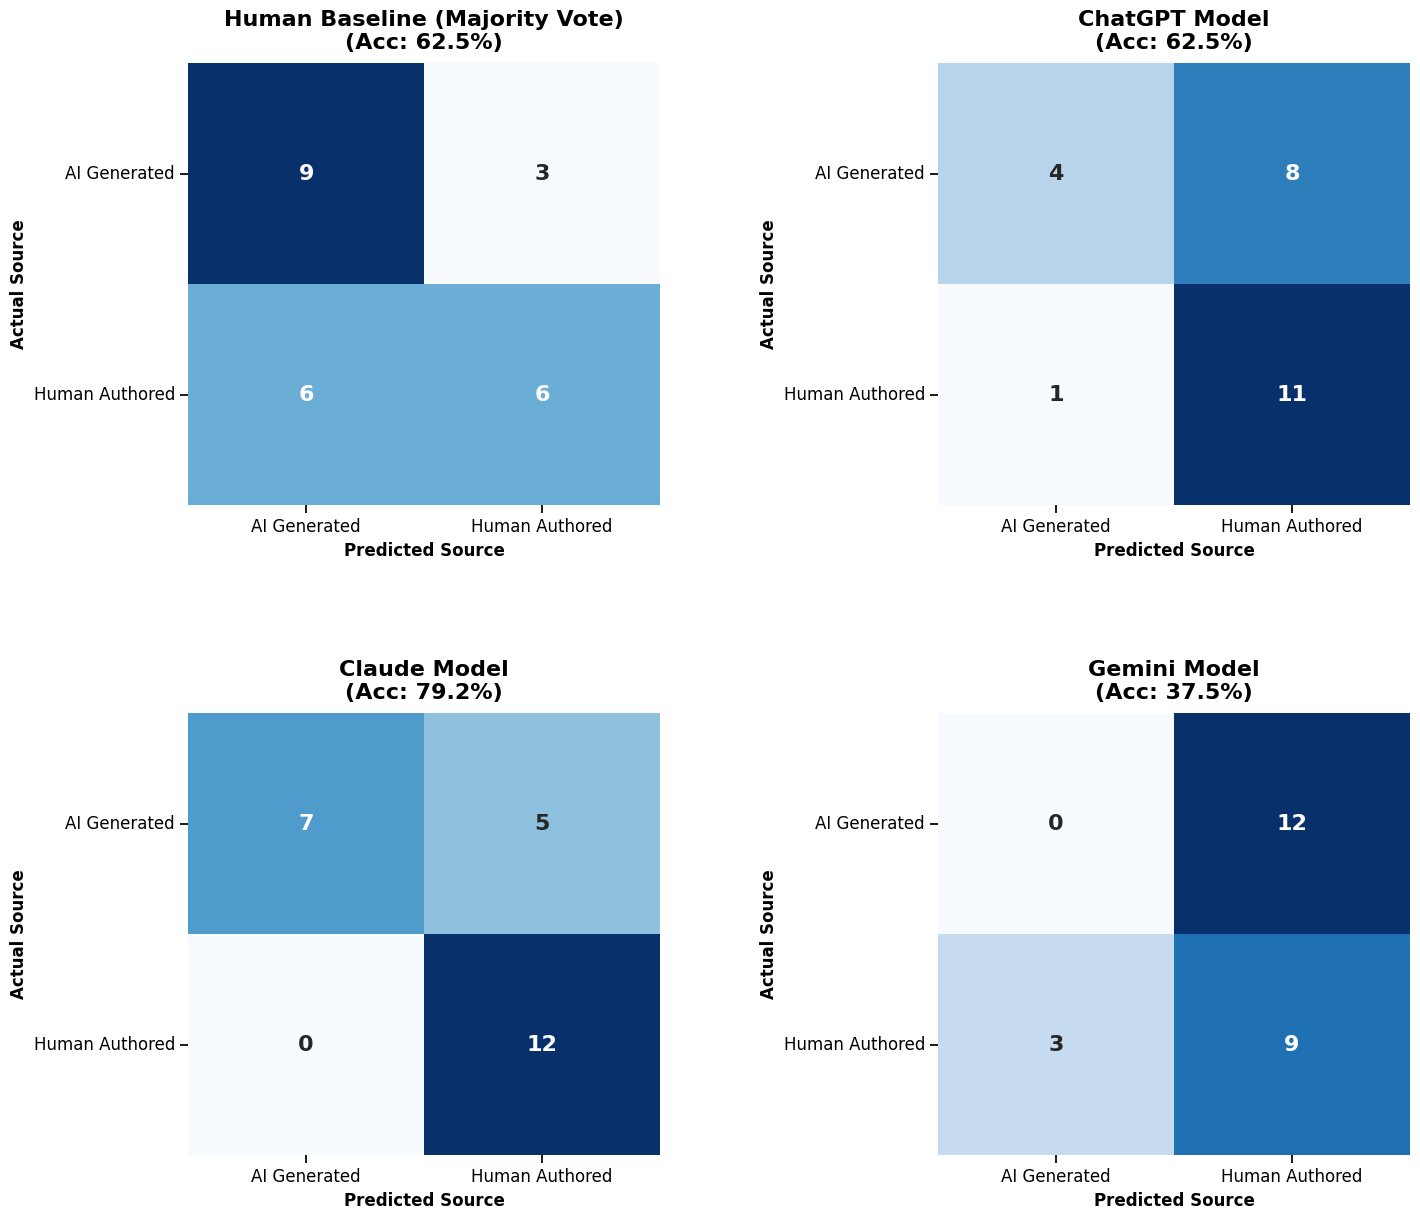

In [55]:
df_master, df_human_raw, loaded_models = load_and_preprocess_data()

print("\n=== RUNNING DETECTION & DECEPTION ANALYSIS ===")
# Setup the figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten() # Flatten to iterate easily (0, 1, 2, 3)

print("\n=== RUNNING CONSOLIDATED DETECTION ANALYSIS ===")

# Analyze Human Baseline 
analyze_detection_performance(
    df_master, 
    "Human Baseline (Majority Vote)", 
    "Human_Majority_Source_Guess", 
    ax=axes_flat[0]
)

# Analyze each AI model 
for i, model in enumerate(loaded_models):
    if i + 1 < len(axes_flat):
        analyze_detection_performance(
            df_master, 
            f"{model} Model", 
            f"{model}_Source", 
            ax=axes_flat[i+1]
        )

# Final layout adjustments
plt.tight_layout(pad=4.0)
plt.show()


=== RUNNING INTER-RATER AGREEMENT ===

[ Inter-Rater Agreement (Variance) ]
  Average Variance among 10 Human Participants: 1.40
  Average Variance among 3 LLMs: 0.38
  Conclusion: LLMs agree with each other MORE than humans do.

=== GENERATING HUMAN NUANCE MATRIX ===


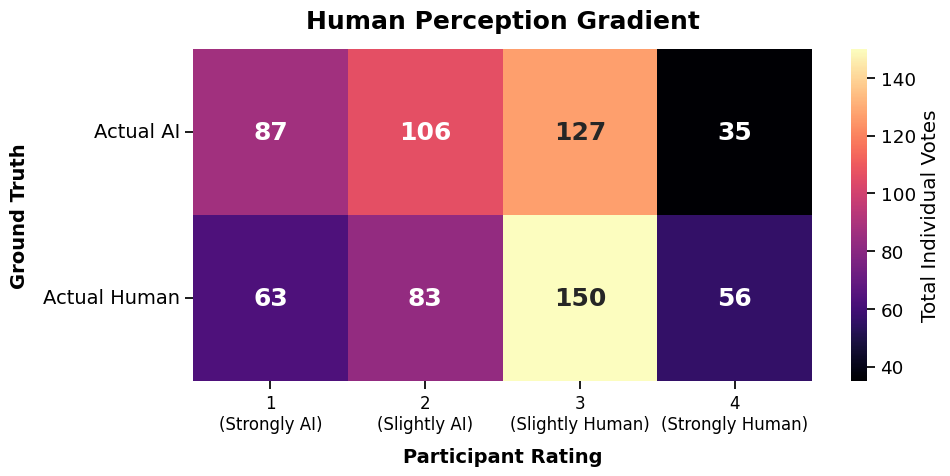

In [57]:
    print("\n=== RUNNING INTER-RATER AGREEMENT ===")
analyze_agreement(df_master, df_human_raw, loaded_models)
    
print("\n=== GENERATING HUMAN NUANCE MATRIX ===")
# Call the nuanced 2x4 matrix for human responses
# TODO: make function for AI nuance matrix
plot_human_nuance_matrix(df_human_raw, GROUND_TRUTH)

In [59]:
from sklearn.metrics import roc_curve, auc

def plot_perception_scatter(df_master, model_name, ax):
    """Plots humor perception alignment for a specific model on a given axis."""
    humor_col = f'{model_name}_Humor'
    
    # Calculate simple bias metric for the title
    bias = df_master[humor_col].mean() - df_master['Human_Mean_Humor'].mean()
    
    # plot the regression line (shows the model's actual rating trend)
    sns.regplot(data=df_master, x='Human_Mean_Humor', y=humor_col, 
                scatter=False, color='blue', ax=ax, label=f'Trend (Bias: +{bias:.2f})')
    
    # plot the individual scatter points
    sns.scatterplot(data=df_master, x='Human_Mean_Humor', y=humor_col, 
                    hue='Actual_Source', palette={'Human': '#2ecc71', 'AI': '#e74c3c'},
                    s=100, edgecolor='black', alpha=0.8, ax=ax)
    
    # reference Line (y=x) - What perfect agreement looks like
    ax.plot([1, 5], [1, 5], 'k--', alpha=0.5, zorder=0, label='Perfect Agreement (y=x)')
    
    # formatting
    ax.set_title(f"Human vs. {model_name}", fontsize=16, weight='bold')
    ax.set_xlabel("Human Mean Rating", fontsize=12)
    ax.set_ylabel(f"{model_name} Rating", fontsize=12)
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=9, loc='upper left')


# Generation Quality Boxplot
def plot_generation_quality(df_master):
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    sns.boxplot(data=df_master, x='Actual_Source', y='Human_Mean_Humor', 
                palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, width=0.5)
    
    sns.stripplot(data=df_master, x='Actual_Source', y='Human_Mean_Humor', 
                  color='black', alpha=0.5, size=8, jitter=True)
    
    plt.title("Generation Quality: Are AI Jokes as Funny as Human Jokes?", weight='bold')
    plt.xlabel("Actual Joke Source")
    plt.ylabel("Funniness Rating (Scored by Humans)")
    plt.tight_layout()
    plt.show()


# Source Detection ROC Curve
def plot_source_detection_roc(df_master, loaded_models):
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    # Ground truth: Convert 'Human' to 1 and 'AI' to 0 for the math to work
    y_true = df_master['Actual_Source'].map({'Human': 1, 'AI': 0})
    
    colors = ['#3498db', '#9b59b6', '#e67e22'] # Blue, Purple, Orange
    
    for i, model in enumerate(loaded_models):
        source_col = f'{model}_Source'
        
        # We need the RAW numeric 1-4 guesses to draw a curve
        if source_col in df_master.columns:
            # We map 1-4 onto a 0.0 - 1.0 probability scale
            y_scores = (df_master[source_col].astype(float) - 1) / 3 
            
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, color=colors[i], lw=2, 
                     label=f'{model} (AUC = {roc_auc:.2f})')
            
    # Add random guessing line
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    
    plt.title('ROC Curve: Source Detection Accuracy', weight='bold')
    plt.xlabel('False Positive Rate (Incorrectly labeling AI as Human)')
    plt.ylabel('True Positive Rate (Correctly identifying Human)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Correlation Matrix
def plot_correlation_matrix(df_master, loaded_models):
    import numpy as np
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    # Select only the humor rating columns for correlation
    cols_to_correlate = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    
    # Calculate the Pearson correlation matrix
    corr_matrix = df_master[cols_to_correlate].corr()
    
    # Clean up the labels for the graph
    clean_labels = ['Human Baseline'] + loaded_models
    corr_matrix.index = clean_labels
    corr_matrix.columns = clean_labels
    
    # Create a mask so we only show the bottom triangle of the matrix (cleaner look)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Draw the heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
                vmin=-1, vmax=1, center=0, square=True, 
                linewidths=.5, cbar_kws={"shrink": .8, 'label': 'Pearson Correlation (r)'},
                annot_kws={"size": 16, "weight": "bold"})
    
    plt.title("Humor Perception Correlation Matrix", weight='bold', pad=15, fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14)
    plt.tight_layout()
    plt.show()

# Intersection Analysis 
def plot_intersection_analysis(df_master, model_name):
    df_temp = df_master.copy()
    humor_col = f'{model_name}_Humor'
    source_col = f'{model_name}_Source'
    
    # Calculate absolute error (Difference from human average)
    df_temp['Humor_Error'] = abs(df_temp[humor_col] - df_temp['Human_Mean_Humor'])
    
    # Check if they got the source right
    model_guesses = df_temp[source_col].apply(lambda x: 'Human' if float(x) > 2.5 else 'AI')
    df_temp['Source_Guess_Correct'] = (model_guesses == df_temp['Actual_Source'])
    df_temp['Source_Guess_Correct'] = df_temp['Source_Guess_Correct'].map({True: 'Correctly Identified', False: 'Incorrectly Identified'})
    
    plt.figure(figsize=(9, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    # Added hue='Source_Guess_Correct' and legend=False
    sns.violinplot(data=df_temp, x='Source_Guess_Correct', y='Humor_Error', 
                   hue='Source_Guess_Correct', legend=False,
                   inner="quartile", palette="muted")
    
    sns.swarmplot(data=df_temp, x='Source_Guess_Correct', y='Humor_Error', 
                  color="black", alpha=0.6, size=7)
    
    plt.title(f"Intersection: Does Knowing the Source Improve Humor Rating?\n({model_name})", weight='bold')
    plt.xlabel("Model's Source Identification Accuracy")
    plt.ylabel("Humor Error\n(Difference from Human Average)")
    plt.tight_layout()
    plt.show()

In [61]:
df_master, df_human_raw, loaded_models = load_and_preprocess_data()

Loading datasets...
  -> Successfully loaded ChatGPT data.
  -> Successfully loaded Claude data.
  -> Successfully loaded Gemini data.



Generating Plot 1: Generation Quality...


/var/folders/4n/kg_g5q5x74s1jbw8wpr9rjcm0000gp/T/ipykernel_55244/580309940.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Actual_Source', y='Human_Mean_Humor',


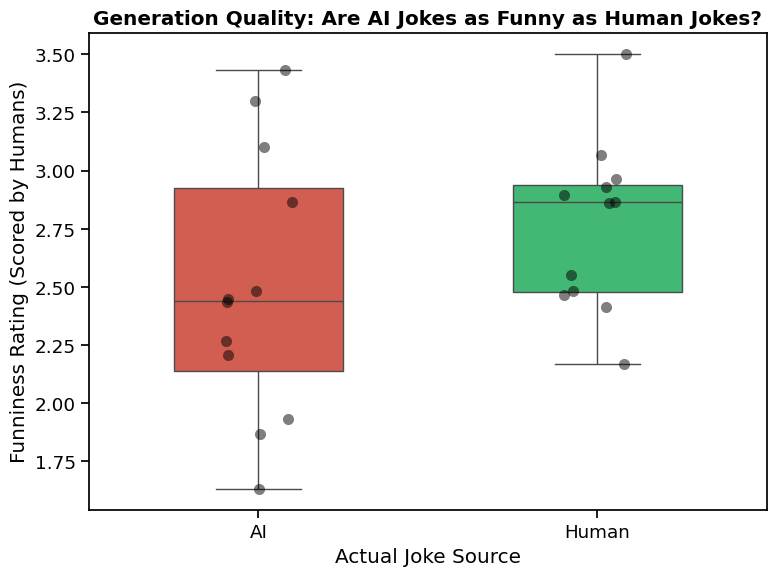

In [63]:
 # --- PLOT 1: Generation Quality ---
print("\nGenerating Plot 1: Generation Quality...")
plot_generation_quality(df_master)


Generating Consolidated Plot 2: Perception Alignment...


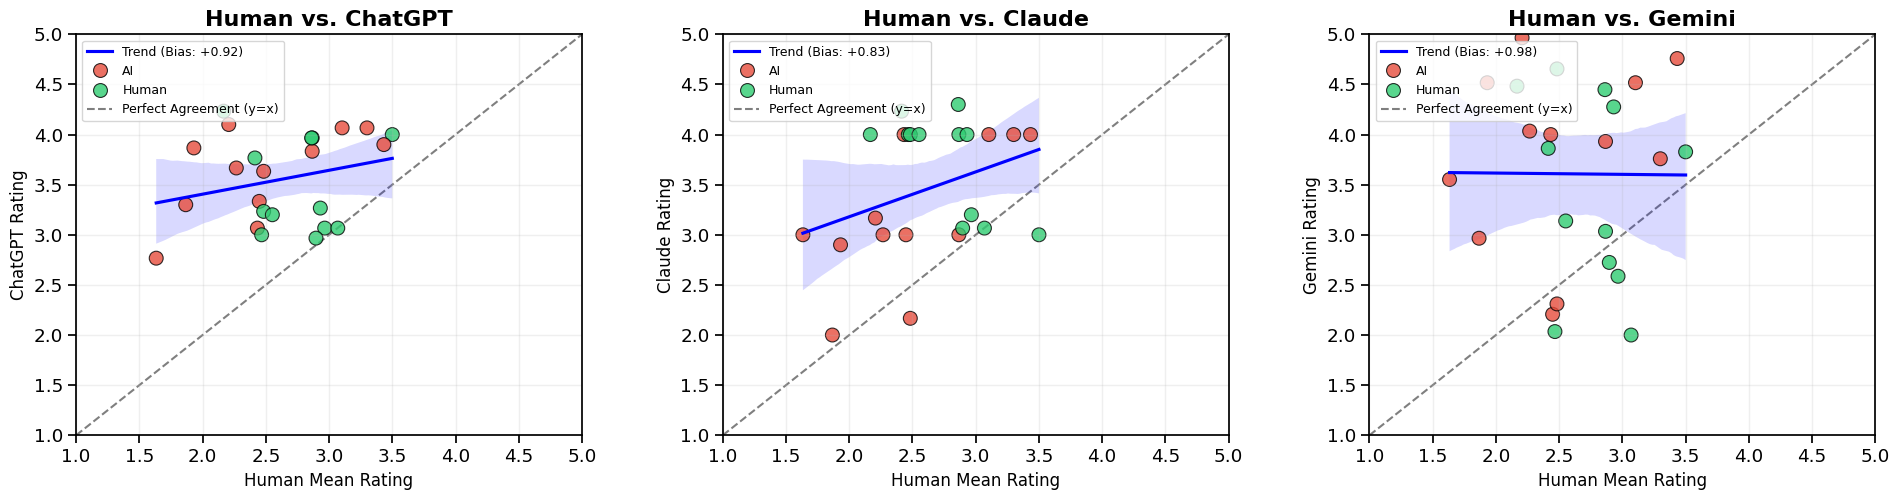


Generating Plot 3: Standardized (Z-Score) Perception Alignment...


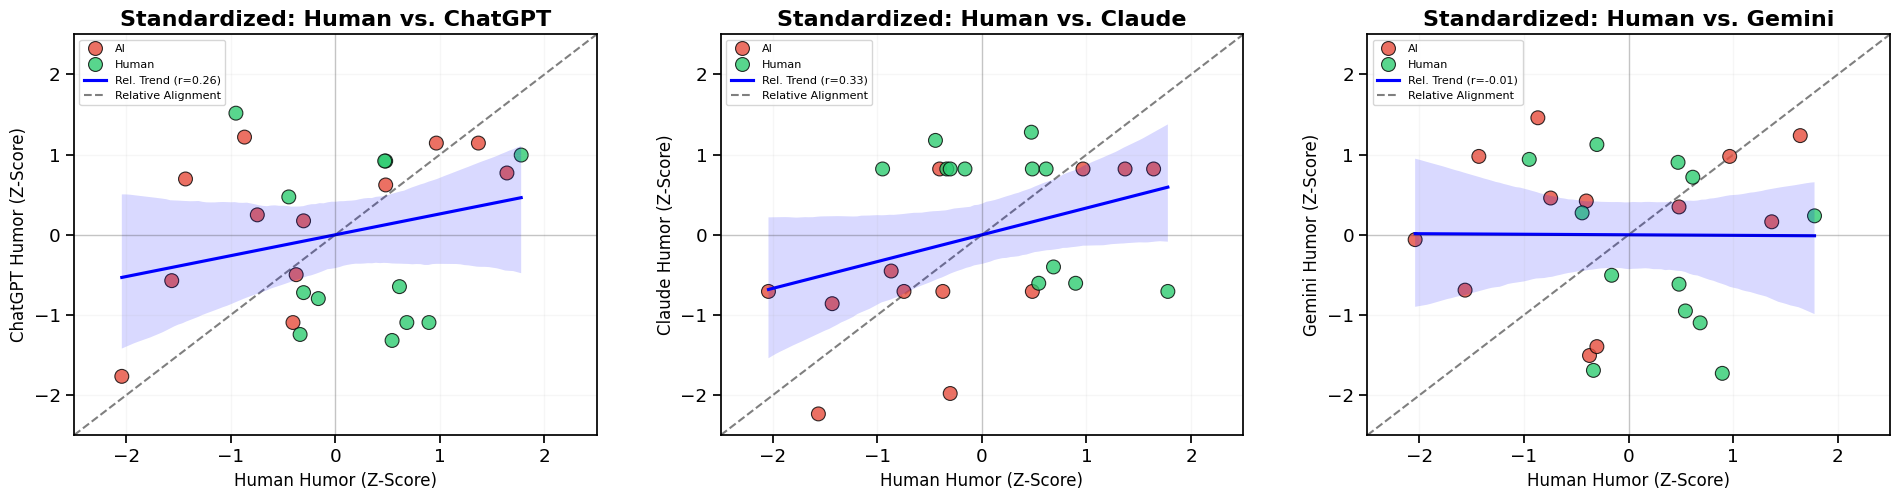

In [61]:
# Setup a 1x3 grid for the three models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

print("\nGenerating Consolidated Plot 2: Perception Alignment...")

for i, model in enumerate(loaded_models):
    if i < 3: # Ensure we don't exceed our 3 columns
        plot_perception_scatter(df_master, model, axes[i])

# Adjust spacing so labels don't overlap
plt.tight_layout(pad=3.0)
plt.show()

def plot_zscore_perception_scatter(df_master, model_name, ax):
    """Plots Z-score normalized humor perception to remove rating bias."""
    humor_col = f'{model_name}_Humor'
    
    # Calculate Z-Scores for this specific model run
    # We do this locally so we don't overwrite your main dataframe
    df_temp = df_master.copy()
    
    # Standardize Human Ratings
    h_mean = df_temp['Human_Mean_Humor'].mean()
    h_std = df_temp['Human_Mean_Humor'].std()
    df_temp['Human_Z'] = (df_temp['Human_Mean_Humor'] - h_mean) / h_std
    
    # Standardize Model Ratings
    m_mean = df_temp[humor_col].mean()
    m_std = df_temp[humor_col].std()
    df_temp['Model_Z'] = (df_temp[humor_col] - m_mean) / m_std
    
    # Calculate Correlation (Pearson r stays the same, but p-value is useful)
    from scipy import stats
    r, p = stats.pearsonr(df_temp['Human_Z'], df_temp['Model_Z'])

    # Plot the Standardized Points
    sns.scatterplot(data=df_temp, x='Human_Z', y='Model_Z', 
                    hue='Actual_Source', palette={'Human': '#2ecc71', 'AI': '#e74c3c'},
                    s=100, edgecolor='black', alpha=0.8, ax=ax)
    
    # Regression Line (The relative trend)
    sns.regplot(data=df_temp, x='Human_Z', y='Model_Z', 
                scatter=False, color='blue', ax=ax, 
                label=f'Rel. Trend (r={r:.2f})')
    
    # Perfect Relative Alignment Line (y=x)
    ax.plot([-3, 3], [-3, 3], 'k--', alpha=0.5, zorder=0, label='Relative Alignment')
    
    # Formatting for Z-score space
    ax.set_title(f"Standardized: Human vs. {model_name}", fontsize=16, weight='bold')
    ax.set_xlabel("Human Humor (Z-Score)", fontsize=12)
    ax.set_ylabel(f"{model_name} Humor (Z-Score)", fontsize=12)
    
    # Z-scores usually fall between -3 and 3
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    
    ax.axhline(0, color='black', lw=1, alpha=0.2) # Zero line for context
    ax.axvline(0, color='black', lw=1, alpha=0.2)
    
    ax.grid(True, alpha=0.1)
    ax.legend(fontsize=8, loc='upper left')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

print("\nGenerating Plot 3: Standardized (Z-Score) Perception Alignment...")

for i, model in enumerate(loaded_models):
    if i < 3:
        plot_zscore_perception_scatter(df_master, model, axes[i])

plt.tight_layout(pad=3.0)
plt.show()


Generating Plot 3: Humor Correlation Matrix...


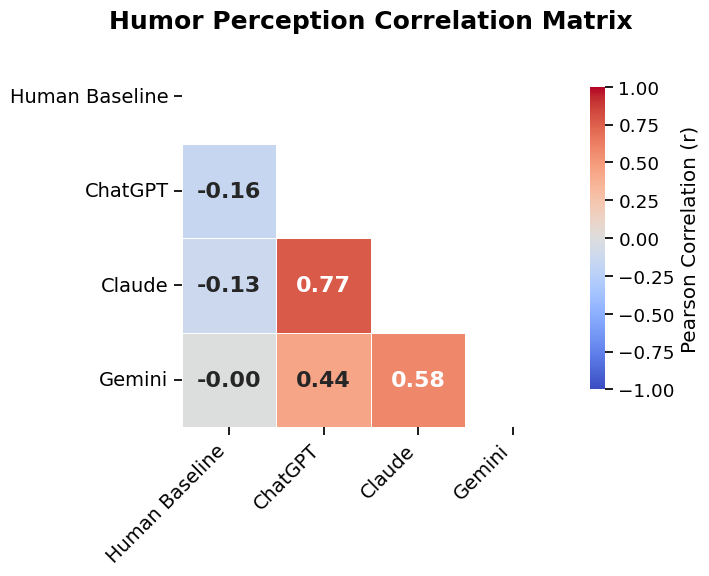

In [13]:
# PLOT 3: Humor Correlation Matrix ---
print("\nGenerating Plot 3: Humor Correlation Matrix...")
# Shows how well Human, ChatGPT, and Gemini all align with each other!
plot_correlation_matrix(df_master, loaded_models)
        


Generating Plot 4: ROC Curve (All Models)...


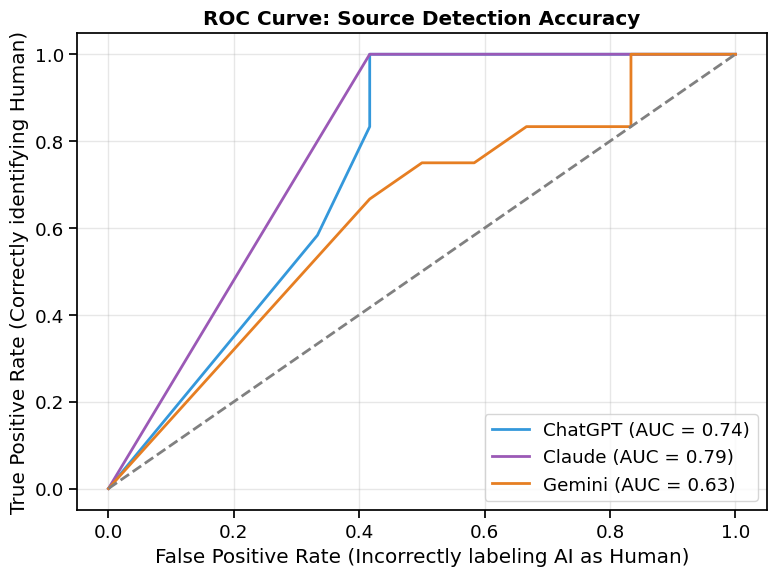

In [63]:
 # --- PLOT 4: Source Detection ROC Curve ---
print("\nGenerating Plot 4: ROC Curve (All Models)...")
plot_source_detection_roc(df_master, loaded_models)

In [15]:
def plot_item_agreement_heatmap(df_master, loaded_models):
    plt.figure(figsize=(15, 5))
    sns.set_context("notebook", font_scale=1.1)
    
    # Grab just the humor rating columns
    cols_to_plot = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    
    # Set the Question Number as the index so it becomes the X-axis
    df_heat = df_master.set_index('Question Number')[cols_to_plot]
    
    # Clean up row labels for the graph
    df_heat.columns = ['Human Baseline'] + loaded_models
    
    # Transpose (.T) so Raters are rows and Questions are columns
    ax = sns.heatmap(df_heat.T, cmap='magma', annot=True, fmt=".1f", 
                     annot_kws={"size": 12, "weight": "bold"},
                     cbar_kws={'label': 'Humor Rating (1-5)'},
                     linewidths=.5)
    
    plt.title("Item-by-Item Agreement: How Funny was Each Joke?", weight='bold', pad=15, fontsize=18)
    plt.xlabel("Joke ID (Question Number)", weight='bold', labelpad=10)
    plt.ylabel("Rater", weight='bold', labelpad=10)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()


Generating Plot 6: Item-by-Item Agreement Heatmap...


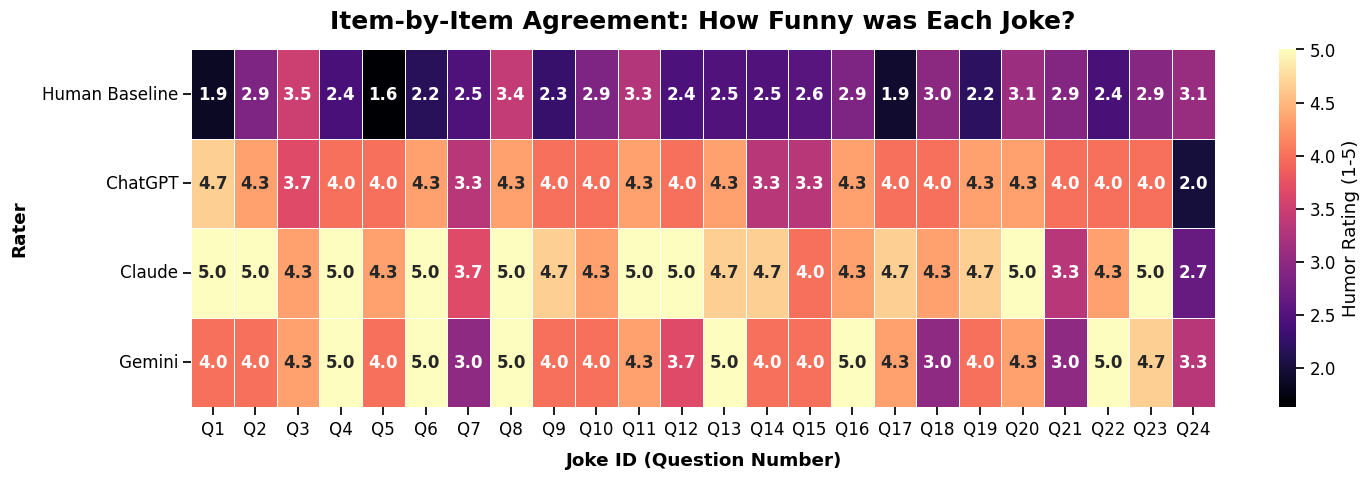

In [16]:
# Plot 6: Item-by-Item Agreement
print("\nGenerating Plot 6: Item-by-Item Agreement Heatmap...")
plot_item_agreement_heatmap(df_master, loaded_models)

In [65]:
def plot_item_divergence_bar(df_master, loaded_models):
    # We need at least 2 entities to have a disagreement!
    cols_to_compare = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    
    if len(cols_to_compare) < 2:
        print("Need at least 1 AI model loaded to calculate divergence.")
        return
        
    df_temp = df_master.copy()
    
    # Calculate the variance across the raters for EACH row (question)
    df_temp['Rating_Variance'] = df_temp[cols_to_compare].var(axis=1)
    
    plt.figure(figsize=(14, 6))
    sns.set_context("notebook", font_scale=1.1)
    
    # Bar plot color-coded by who actually wrote the joke
    sns.barplot(data=df_temp, x='Question Number', y='Rating_Variance', 
                hue='Actual_Source', dodge=False, 
                palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, edgecolor='black')
    
    plt.title("Humor Disagreement: Which Jokes Caused the Most Confusion?", weight='bold', fontsize=18, pad=15)
    plt.ylabel("Variance (Disagreement Level)", weight='bold')
    plt.xlabel("Joke ID (Question Number)", weight='bold')
    plt.xticks(rotation=45)
    plt.legend(title="Actual Joke Source")
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

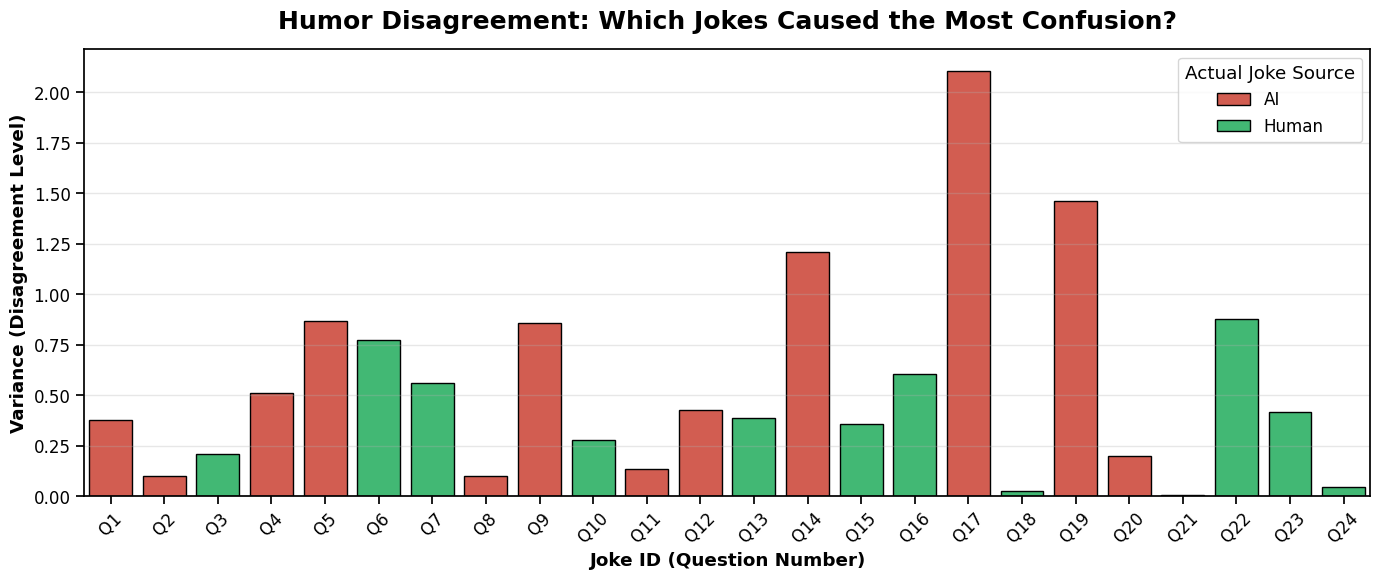

In [67]:
# Plot 7: Item Divergence Bar
plot_item_divergence_bar(df_master, loaded_models)

In [69]:
def plot_spearman_correlation_matrix(df_master, loaded_models):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    cols_to_correlate = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    corr_matrix = df_master[cols_to_correlate].corr(method='spearman')
    
    clean_labels = ['Human Baseline'] + loaded_models
    corr_matrix.index = clean_labels
    corr_matrix.columns = clean_labels
    
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", 
                vmin=-1, vmax=1, center=0, square=True, 
                linewidths=.5, cbar_kws={"shrink": .8, 'label': "Spearman's ρ"},
                annot_kws={"size": 18, "weight": "bold"})
    
    plt.title("Relative Humor Agreement Matrix\n(Spearman Rank Correlation)", weight='bold', pad=15, fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14)
    plt.tight_layout()
    plt.show()

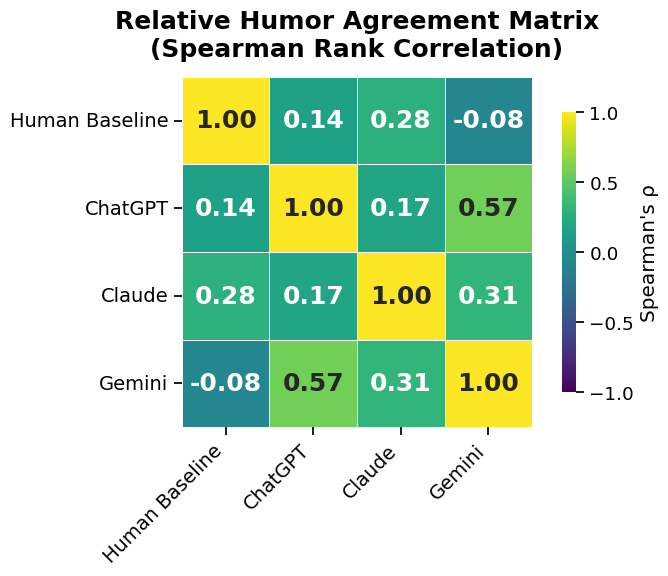

In [87]:
plot_spearman_correlation_matrix(df_master, loaded_models)

In [71]:
def plot_perceived_source_bias(df_master, model_name):
    import scipy.stats as stats
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Route the correct columns based on who we are evaluating
    if model_name == 'Human Baseline':
        humor_col = 'Human_Mean_Humor'
        guess_col = 'Human_Majority_Source_Guess'
    else:
        humor_col = f'{model_name}_Humor'
        guess_col = f'{model_name}_Source'
        
    df_temp = df_master.dropna(subset=[humor_col, guess_col]).copy()
    
    # Ensure the guess column is text ('Human' or 'AI')
    if pd.api.types.is_numeric_dtype(df_temp[guess_col]):
        df_temp['Guessed_Source'] = df_temp[guess_col].apply(lambda x: 'Human' if float(x) > 2.5 else 'AI')
    else:
        df_temp['Guessed_Source'] = df_temp[guess_col]
        
    # Statistical T-Test
    ai_guesses = df_temp[df_temp['Guessed_Source'] == 'AI'][humor_col]
    human_guesses = df_temp[df_temp['Guessed_Source'] == 'Human'][humor_col]
    
    # Only run the t-test if we have at least one guess in both categories
    if len(ai_guesses) > 0 and len(human_guesses) > 0:
        t_stat, p_val = stats.ttest_ind(ai_guesses, human_guesses, nan_policy='omit')
        p_val_str = f"p = {p_val:.3f}"
        
        print(f"\n[ The 'Turing Bias' T-Test: {model_name} ]")
        print(f"  Avg Humor when guessed 'AI':    {ai_guesses.mean():.2f}")
        print(f"  Avg Humor when guessed 'Human': {human_guesses.mean():.2f}")
        if p_val < 0.05:
            print("  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.")
        else:
            print("  Conclusion: NO SIGNIFICANT BIAS. Assumed author does not affect the score.")
    else:
        p_val_str = "N/A (Missing Data)"

    # Plots!
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    sns.violinplot(data=df_temp, x='Guessed_Source', y=humor_col, 
                   hue='Guessed_Source', legend=False,
                   palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, inner="quartile")
    
    sns.swarmplot(data=df_temp, x='Guessed_Source', y=humor_col, 
                  color="black", alpha=0.6, size=7)
    
    plt.title(f"The 'Turing Bias': {model_name}\nDoes perceived author affect the score?", weight='bold', pad=15)
    plt.xlabel("What the Rater THOUGHT the Source Was", weight='bold')
    plt.ylabel("Given Humor Rating (1-5)", weight='bold')
    plt.ylim(0.5, 5.5)
    
    # Add a text annotation for the p-value on the chart
    plt.text(0.5, 0.05, f"T-Test: {p_val_str}", transform=plt.gca().transAxes, 
             ha='center', va='bottom', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()


Generating Plot 8: Perceived Source Bias (Turing Bias)...

[ The 'Turing Bias' T-Test: Human Baseline ]
  Avg Humor when guessed 'AI':    2.40
  Avg Humor when guessed 'Human': 3.02
  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.


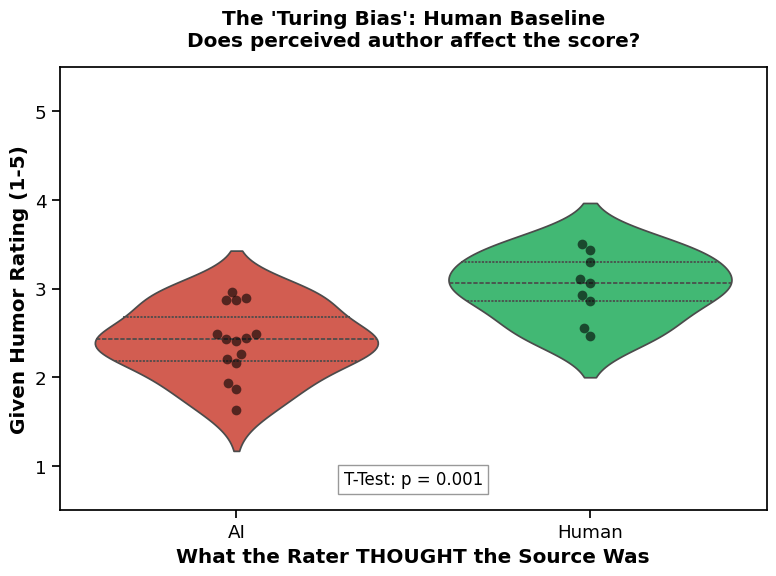


[ The 'Turing Bias' T-Test: ChatGPT ]
  Avg Humor when guessed 'AI':    3.47
  Avg Humor when guessed 'Human': 3.48
  Conclusion: NO SIGNIFICANT BIAS. Assumed author does not affect the score.


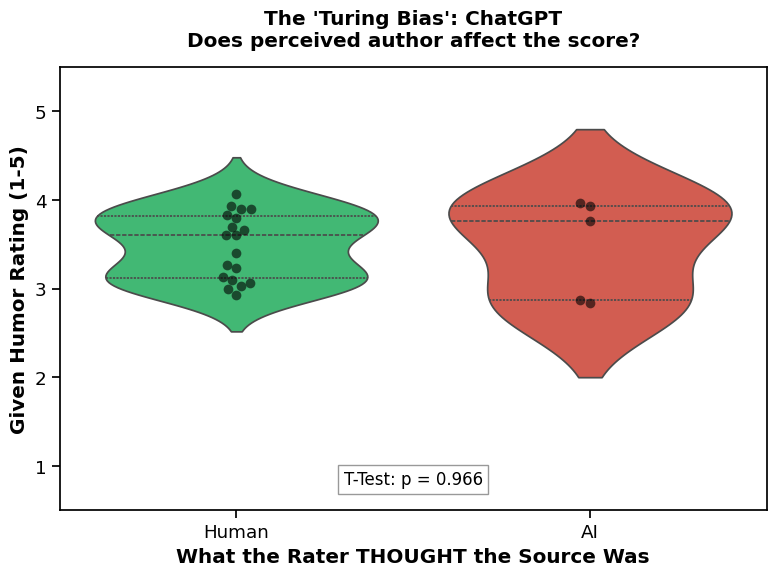


[ The 'Turing Bias' T-Test: Claude ]
  Avg Humor when guessed 'AI':    2.58
  Avg Humor when guessed 'Human': 3.83
  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.


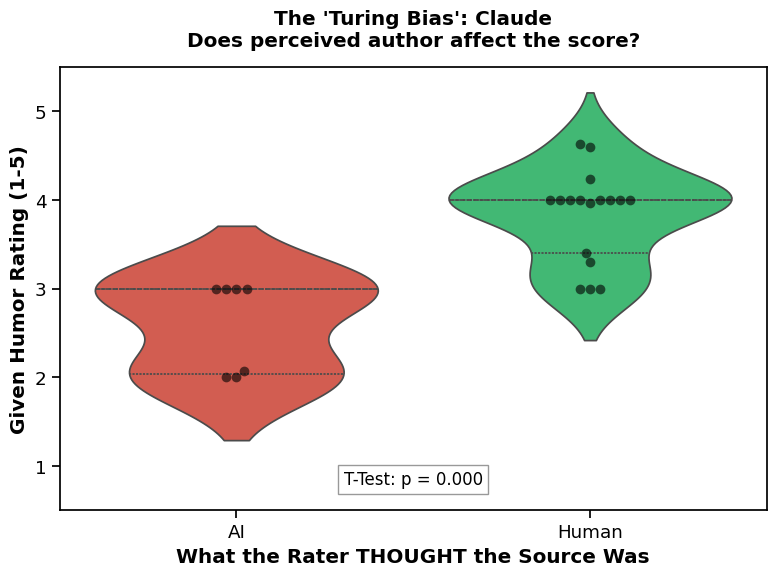


[ The 'Turing Bias' T-Test: Gemini ]
  Avg Humor when guessed 'AI':    2.72
  Avg Humor when guessed 'Human': 3.82
  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.


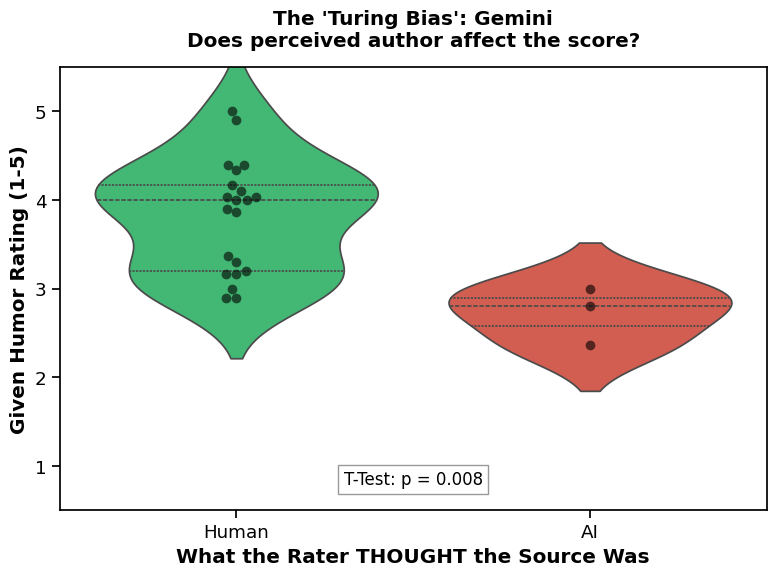


=== VISUAL ANALYSIS COMPLETE ===


In [73]:

# --- PLOT 8: The "Turing Bias" (Perceived Source Bias) ---
print("\nGenerating Plot 8: Perceived Source Bias (Turing Bias)...")

# Run it for the Human Baseline first
plot_perceived_source_bias(df_master, 'Human Baseline')

# Run it for all loaded AI models
for model in loaded_models:
    plot_perceived_source_bias(df_master, model)
    
print("\n=== VISUAL ANALYSIS COMPLETE ===")

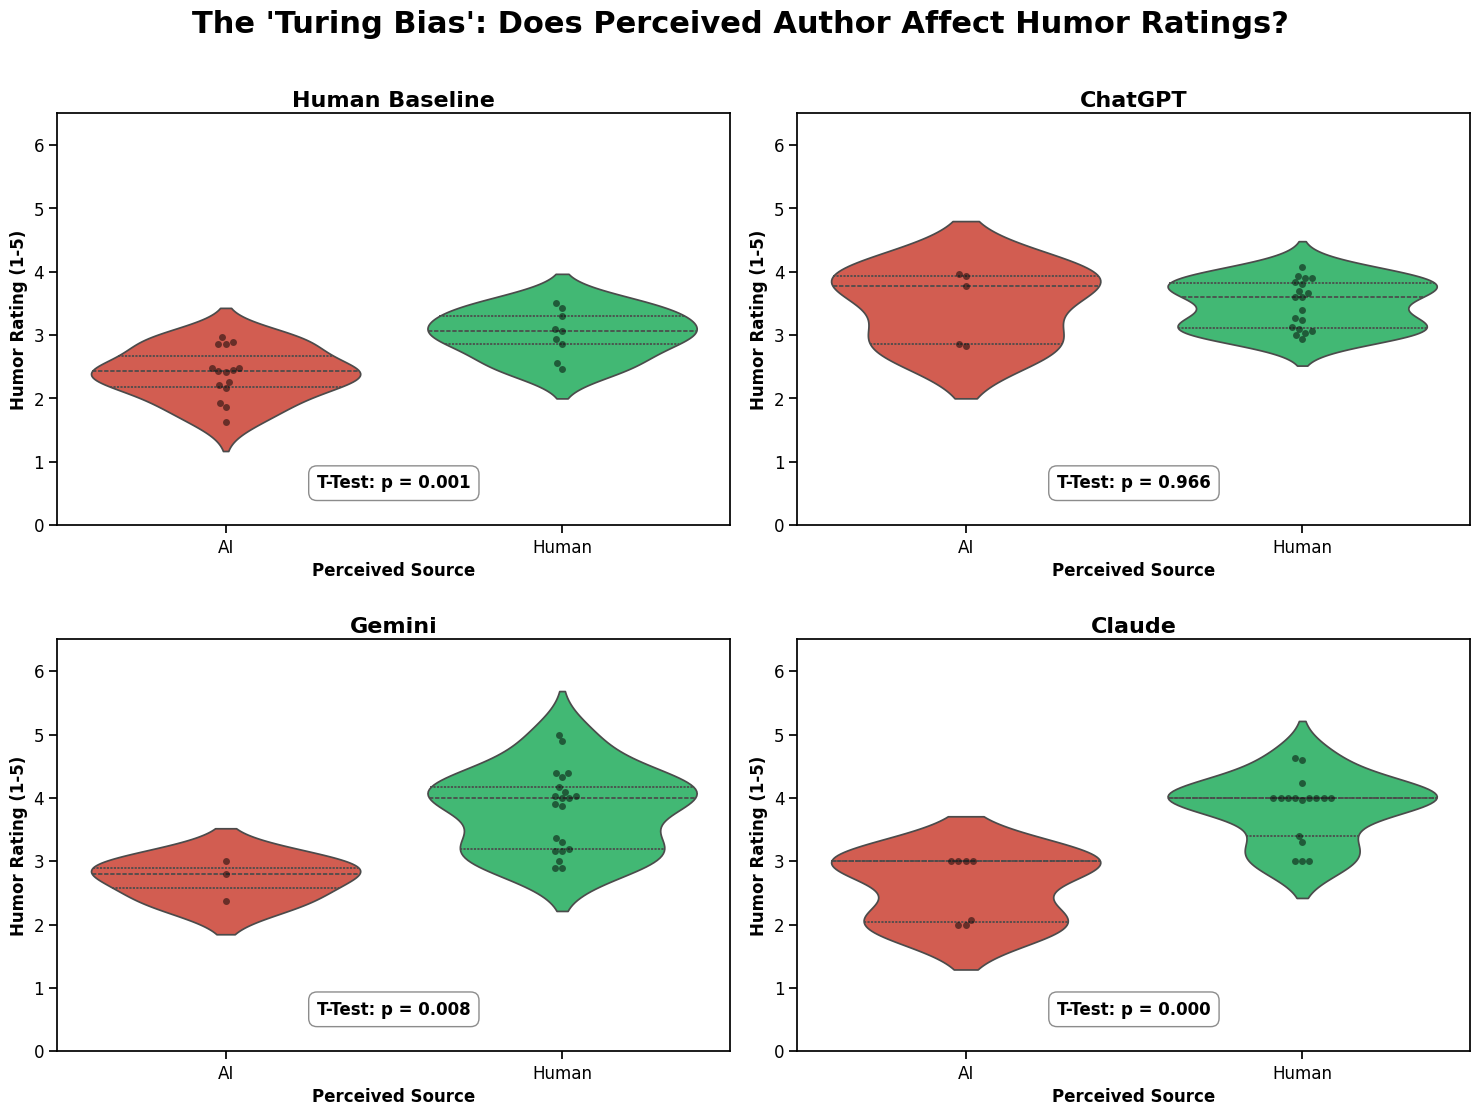

In [83]:
def plot_perceived_source_bias_subplot(df_master, model_name, ax):
    """Modified version with fixed X-axis ordering and tight spacing."""
    if model_name == 'Human Baseline':
        humor_col = 'Human_Mean_Humor'
        guess_col = 'Human_Majority_Source_Guess'
    else:
        humor_col = f'{model_name}_Humor'
        guess_col = f'{model_name}_Source'
        
    if humor_col not in df_master.columns or guess_col not in df_master.columns:
        ax.set_title(f"{model_name} (Data Not Found)")
        return

    df_temp = df_master.dropna(subset=[humor_col, guess_col]).copy()
    
    if pd.api.types.is_numeric_dtype(df_temp[guess_col]):
        df_temp['Guessed_Source'] = df_temp[guess_col].apply(lambda x: 'Human' if float(x) > 2.5 else 'AI')
    else:
        df_temp['Guessed_Source'] = df_temp[guess_col]
        
    ai_guesses = df_temp[df_temp['Guessed_Source'] == 'AI'][humor_col]
    human_guesses = df_temp[df_temp['Guessed_Source'] == 'Human'][humor_col]
    
    p_val_str = "N/A"
    if len(ai_guesses) > 1 and len(human_guesses) > 1:
        t_stat, p_val = stats.ttest_ind(ai_guesses, human_guesses, nan_policy='omit')
        p_val_str = f"p = {p_val:.3f}"

    # --- FIXED ORDERING HERE ---
    target_order = ['AI', 'Human']

    sns.violinplot(data=df_temp, x='Guessed_Source', y=humor_col, ax=ax,
                   hue='Guessed_Source', order=target_order, legend=False,
                   palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, inner="quartile")
    
    sns.swarmplot(data=df_temp, x='Guessed_Source', y=humor_col, ax=ax,
                  order=target_order, color="black", alpha=0.5, size=5)
    
    # Titles and labels
    ax.set_title(f"{model_name}", weight='bold', size=16, pad=5) 
    ax.set_xlabel("Perceived Source", weight='bold', size=12)
    ax.set_ylim(0, 6.5) 
    ax.set_ylabel("Humor Rating (1-5)", weight='bold', size=12)
    
    ax.text(0.5, 0.08, f"T-Test: {p_val_str}", transform=ax.transAxes, 
             ha='center', va='bottom', fontsize=12, weight='bold',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# --- MAIN EXECUTION ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.set_context("notebook", font_scale=1.1)

model_grid = [
    ('Human Baseline', axes[0, 0]),
    ('ChatGPT', axes[0, 1]),
    ('Gemini', axes[1, 0]),
    ('Claude', axes[1, 1])
]

for model_name, ax in model_grid:
    plot_perceived_source_bias_subplot(df_master, model_name, ax)

plt.suptitle("The 'Turing Bias': Does Perceived Author Affect Humor Ratings?", 
             weight='bold', fontsize=22, y=0.96)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0) 
plt.show()

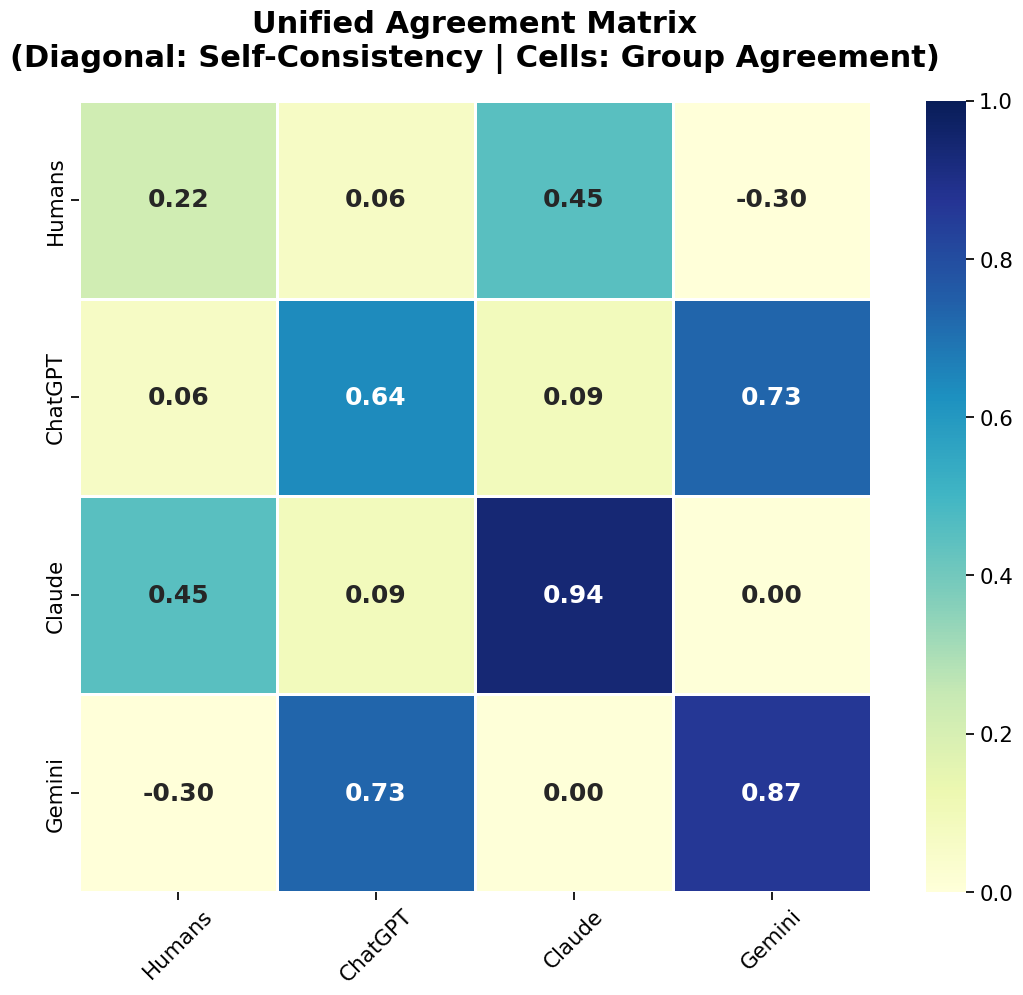

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import re
import os

def clean_q_number(val):
    """Safely converts 'Q1', 1.0, or '1' into integer 1."""
    if pd.isna(val): return None
    if isinstance(val, str):
        match = re.search(r'(\d+)', val)
        return int(match.group(1)) if match else None
    return int(float(val))

def calculate_intra_agreement(df_raw, is_human=False):
    """Calculates internal consistency using Leave-One-Out Spearman logic."""
    rhos = []
    if is_human:
        # For humans, treat each of the 10 participants as a 'trial'
        humor_cols = [c for c in df_raw.columns if 'Rate how humorous' in c]
        for col in humor_cols:
            ratings = df_raw[col].dropna().values
            if len(ratings) > 1:
                for i in range(len(ratings)):
                    rhos.append((ratings[i], np.delete(ratings, i).mean()))
    else:
        # For AI, use the 30 trials per joke
        q_col = 'Question_Number' if 'Question_Number' in df_raw.columns else 'Question Number'
        for _, group in df_raw.groupby(q_col):
            ratings = group['Humor_Rating'].values
            if len(ratings) > 1:
                for i in range(len(ratings)):
                    rhos.append((ratings[i], np.delete(ratings, i).mean()))
    
    if not rhos: return 0.0
    rho, _ = stats.spearmanr([r[0] for r in rhos], [r[1] for r in rhos])
    return rho

def main_square_matrix():
    model_list = ["ChatGPT", "Claude", "Gemini"]
    
    # Using your uploaded Form Responses file
    df_human_raw = pd.read_csv('NIAI_Responses - Form Responses 1.csv')
    humor_cols = [c for c in df_human_raw.columns if re.match(r'^Q\d+\.', c) and 'Rate how humorous' in c]
    
    human_data = []
    for col in humor_cols:
        q_num = clean_q_number(col)
        human_data.append({'Question Number': q_num, 'Human_Mean_Humor': df_human_raw[col].mean()})
    
    summary_df = pd.DataFrame(human_data)
    intra_scores = {'Humans': calculate_intra_agreement(df_human_raw, is_human=True)}

    # Add AI Data from Raw Files
    for model in model_list:
        filename = f'RAW_Data_{model}_Batch.csv'
        if os.path.exists(filename):
            df_raw = pd.read_csv(filename)
            q_col = 'Question_Number' if 'Question_Number' in df_raw.columns else 'Question Number'
            
            # Add to Summary
            m_means = df_raw.groupby(q_col)['Humor_Rating'].mean().reset_index()
            m_means.columns = ['Question Number', f'{model}_Humor']
            m_means['Question Number'] = m_means['Question Number'].apply(clean_q_number)
            summary_df = pd.merge(summary_df, m_means, on='Question Number', how='left')
            
            # Calculate Diagonal (Intra)
            intra_scores[model] = calculate_intra_agreement(df_raw)

    # Create the Matrix
    cols_to_corr = ['Human_Mean_Humor'] + [f'{m}_Humor' for m in model_list if f'{m}_Humor' in summary_df.columns]
    corr_matrix = summary_df[cols_to_corr].corr(method='spearman')
    
    # Clean Labels
    name_map = {f'{m}_Humor': m for m in model_list}
    name_map['Human_Mean_Humor'] = 'Humans'
    corr_matrix = corr_matrix.rename(columns=name_map, index=name_map)

    # Set the Diagonal to Intra-rater scores
    for label, score in intra_scores.items():
        if label in corr_matrix.index:
            corr_matrix.loc[label, label] = score

    # Plot Full Square Matrix
    plt.figure(figsize=(12, 10))
    sns.set_context("notebook", font_scale=1.4)
    
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
                vmin=0, vmax=1, square=True, linewidths=2,
                annot_kws={"size": 18, "weight": "bold"})

    plt.title("Unified Agreement Matrix\n(Diagonal: Self-Consistency | Cells: Group Agreement)",
              fontsize=22, weight='bold', pad=25)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Run the matrix generation
main_square_matrix()

--- Initializing Data ---


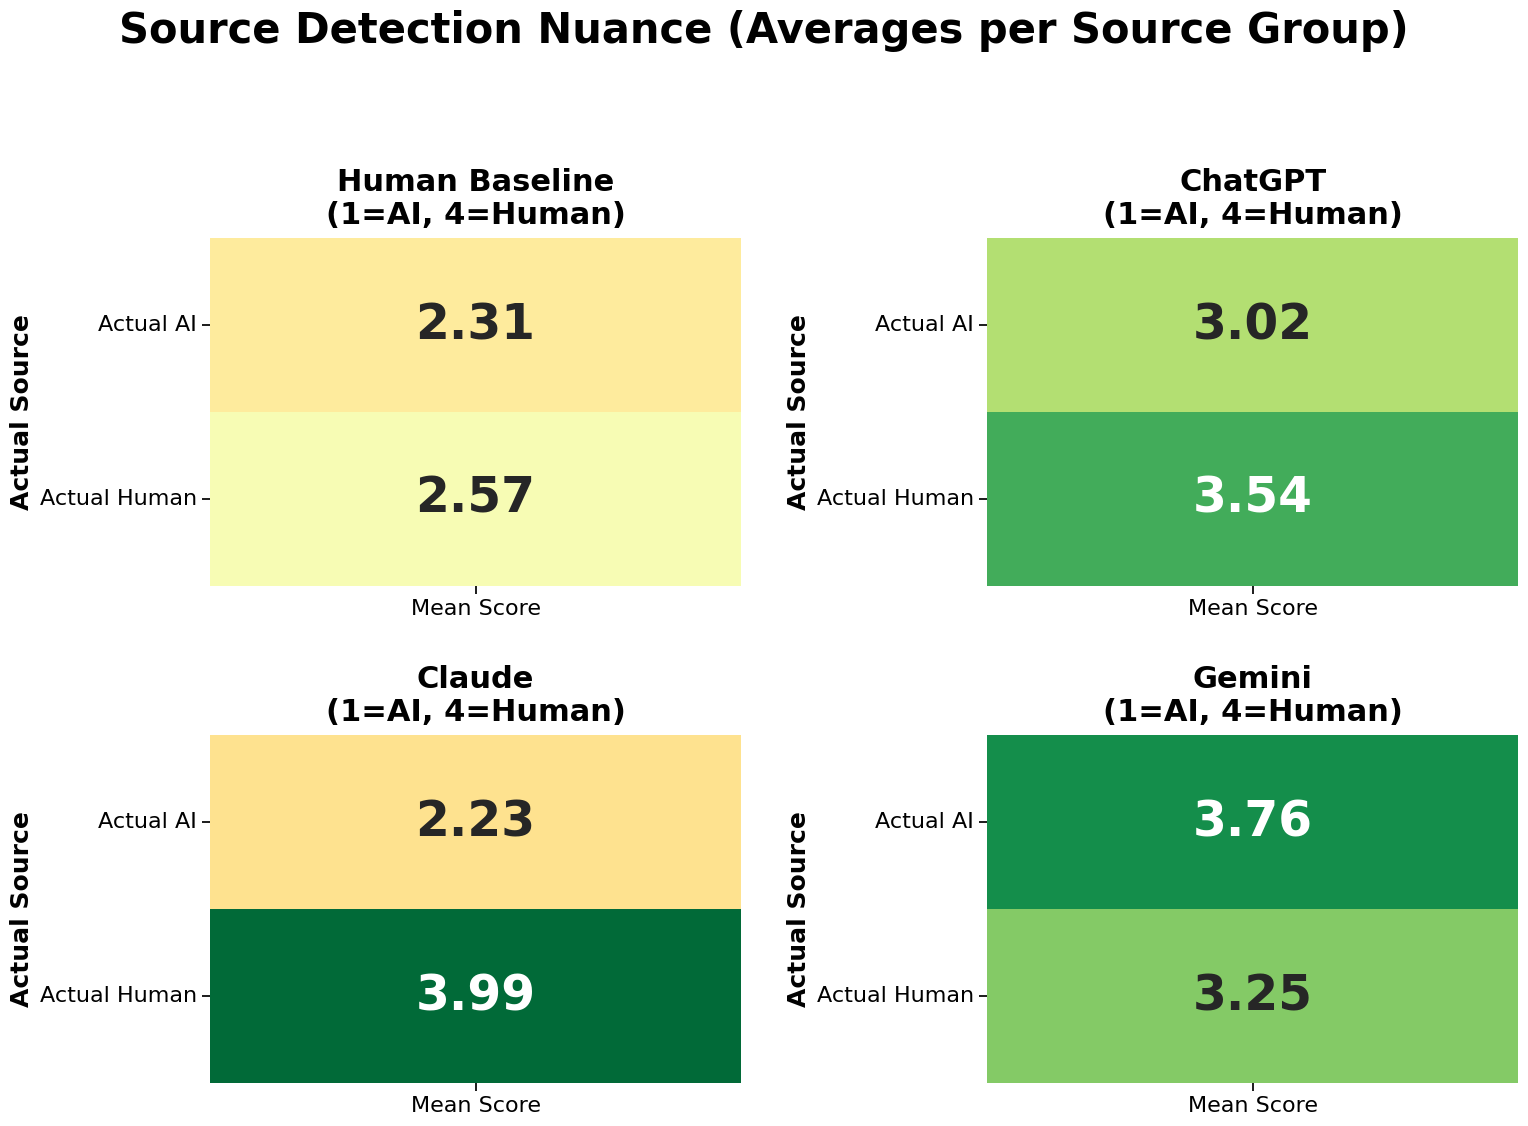

In [93]:


# --- 1. SETUP & DATA CLEANING ---
ground_truth_dict = {
    1: 'AI', 2: 'AI', 3: 'Human', 4: 'AI', 5: 'AI', 6: 'Human', 7: 'Human', 8: 'AI',
    9: 'AI', 10: 'Human', 11: 'AI', 12: 'AI', 13: 'Human', 14: 'AI', 15: 'Human', 16: 'Human',
    17: 'AI', 18: 'Human', 19: 'AI', 20: 'AI', 21: 'Human', 22: 'Human', 23: 'Human', 24: 'Human'
}

def clean_q_number(val):
    """Converts 'Q1' or 1.0 to integer 1."""
    if pd.isna(val): return None
    if isinstance(val, str):
        match = re.search(r'(\d+)', val)
        return int(match.group(1)) if match else None
    return int(float(val))

def get_raw_human_source_data():
    """Generates a long-format dataframe of individual human participant votes."""
    df_human_raw = pd.read_csv('NIAI_Responses - Form Responses 1.csv')
    source_cols = [c for c in df_human_raw.columns if 'human or AI' in c]
    rows = []
    for col in source_cols:
        q_num = clean_q_number(col)
        actual = ground_truth_dict.get(q_num)
        # Ensure ratings are numeric
        ratings = pd.to_numeric(df_human_raw[col], errors='coerce').dropna().values
        for r in ratings:
            rows.append({'Question_Number': q_num, 'Source_Rating': r, 'Actual_Source': actual})
    return pd.DataFrame(rows)

# --- 2. PLOTTING FUNCTION ---
def plot_nuanced_square(df_raw, rater_name, ax):
    """Creates a Square heatmap showing Mean Human-ness Ratings."""
    q_col = 'Question_Number' if 'Question_Number' in df_raw.columns else 'Question Number'
    r_col = 'Source_Rating' if 'Source_Rating' in df_raw.columns else 'Source_Detection'
    
    # Calculate means per ground-truth group
    means = df_raw.groupby('Actual_Source')[r_col].mean().to_frame()
    means.columns = ['Mean Rating']
    
    # Reindex to ensure AI is at the top (Red end) and Human is at the bottom (Green end)
    means = means.reindex(['AI', 'Human'])
    
    # Red-Yellow-Green scale (1=AI=Red, 4=Human=Green)
    sns.heatmap(means, annot=True, fmt=".2f", cmap="RdYlGn", 
                vmin=1, vmax=4, ax=ax, cbar=False,
                annot_kws={"size": 35, "weight": "bold"})
    
    ax.set_title(f"{rater_name}\n(1=AI, 4=Human)", fontsize=22, weight='bold', pad=10)
    ax.set_ylabel("Actual Source", fontsize=18, weight='bold')
    ax.set_yticklabels(["Actual AI", "Actual Human"], fontsize=16, rotation=0)
    ax.set_xticklabels(["Mean Score"], fontsize=16)

# --- 3. MAIN EXECUTION ---
print("--- Initializing Data ---")
df_human_trials = get_raw_human_source_data()
models = ["ChatGPT", "Claude", "Gemini"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

# Plot Human Baseline
plot_nuanced_square(df_human_trials, "Human Baseline", axes_flat[0])

# Plot AI Models
for i, model in enumerate(models):
    filename = f'RAW_Data_{model}_Batch.csv'
    if os.path.exists(filename):
        df_ai_raw = pd.read_csv(filename)
        df_ai_raw['Actual_Source'] = df_ai_raw['Question_Number'].map(ground_truth_dict)
        plot_nuanced_square(df_ai_raw, model, axes_flat[i+1])
    else:
        axes_flat[i+1].text(0.5, 0.5, f"File Not Found:\n{filename}", ha='center')

# Reduce 'y' to pull the title down
plt.suptitle("Source Detection Nuance (Averages per Source Group)", 
             fontsize=30, weight='bold', y=0.96)

# Use 'rect' to define the boundary for the subplots, pulling them up toward the title
plt.tight_layout(rect=[0, 0, 1, 0.94], pad=2.5)
plt.show()

/var/folders/4n/kg_g5q5x74s1jbw8wpr9rjcm0000gp/T/ipykernel_55244/3261645221.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Humor_Delta', y='Joke_Label', data=df_compare, palette=colors)


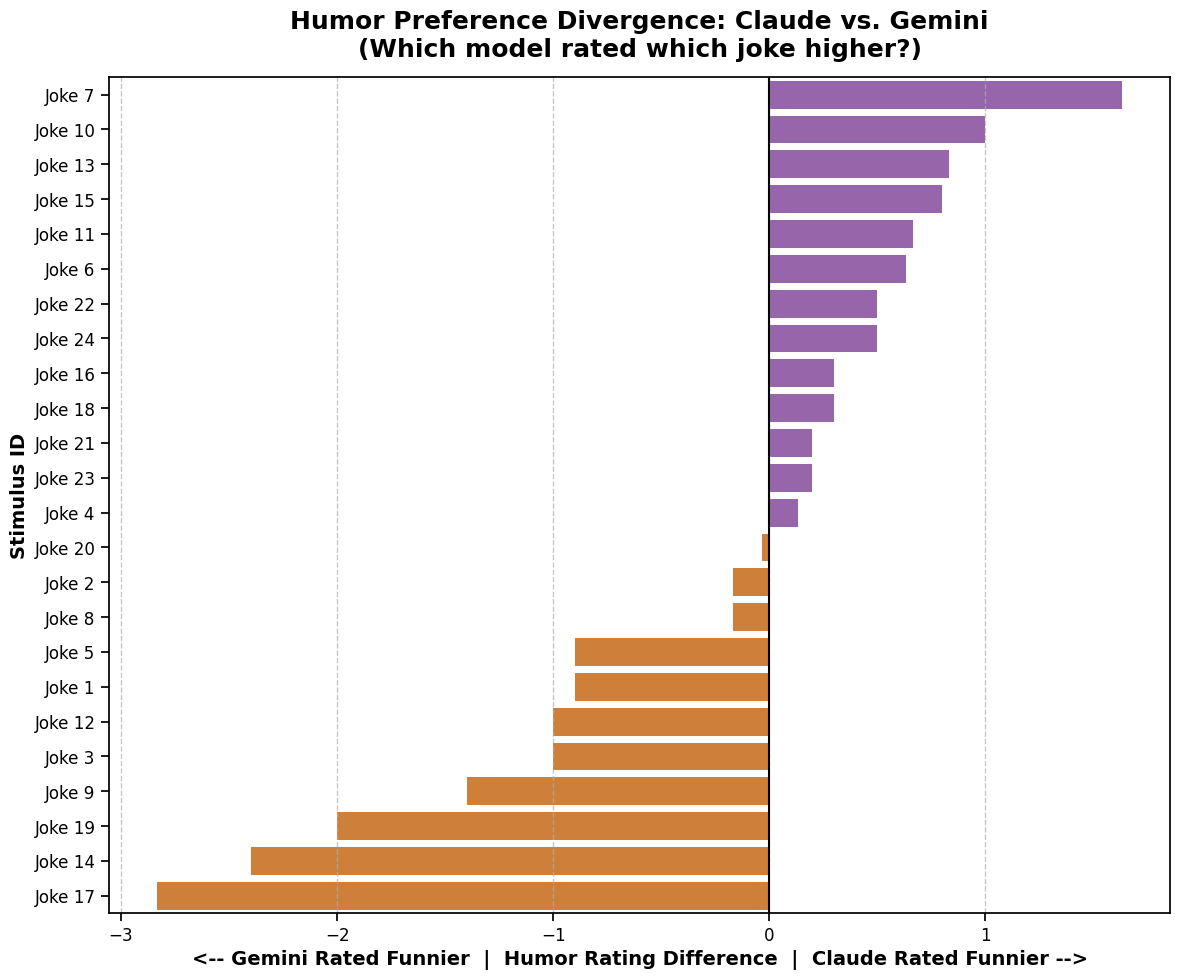

--- Top 3 Jokes Claude Preferred Over Gemini ---
 Question_Number  Claude_Mean  Gemini_Mean  Humor_Delta
               7          4.0     2.366667     1.633333
              10          4.0     3.000000     1.000000
              13          4.0     3.166667     0.833333

--- Top 3 Jokes Gemini Preferred Over Claude ---
 Question_Number  Claude_Mean  Gemini_Mean  Humor_Delta
              19     3.000000          5.0    -2.000000
              14     2.000000          4.4    -2.400000
              17     2.066667          4.9    -2.833333


In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# load the raw batch data for both models
df_claude = pd.read_csv('RAW_Data_Claude_Batch.csv')
df_gemini = pd.read_csv('RAW_Data_Gemini_Batch.csv')

# Standardize column names just in case
c_q_col = 'Question_Number' if 'Question_Number' in df_claude.columns else 'Question Number'
g_q_col = 'Question_Number' if 'Question_Number' in df_gemini.columns else 'Question Number'

# calculate the mean Humor Rating per joke for each model
claude_means = df_claude.groupby(c_q_col)['Humor_Rating'].mean().reset_index()
claude_means.rename(columns={'Humor_Rating': 'Claude_Mean'}, inplace=True)

gemini_means = df_gemini.groupby(g_q_col)['Humor_Rating'].mean().reset_index()
gemini_means.rename(columns={'Humor_Rating': 'Gemini_Mean'}, inplace=True)

# merge and calculate the Delta (Difference)
df_compare = pd.merge(claude_means, gemini_means, left_on=c_q_col, right_on=g_q_col)
# Positive Delta = Claude liked it more. Negative Delta = Gemini liked it more.
df_compare['Humor_Delta'] = df_compare['Claude_Mean'] - df_compare['Gemini_Mean']

# sort by the Delta for the diverging chart
df_compare = df_compare.sort_values(by='Humor_Delta', ascending=False)
df_compare['Joke_Label'] = "Joke " + df_compare[c_q_col].astype(str)

# plotting the Diverging Bar Chart
plt.figure(figsize=(12, 10))

# Color mapping: Purple for Claude-leaning, Orange for Gemini-leaning
colors = ['#9b59b6' if x > 0 else '#e67e22' for x in df_compare['Humor_Delta']]

sns.barplot(x='Humor_Delta', y='Joke_Label', data=df_compare, palette=colors)

# Formatting
plt.axvline(0, color='black', linewidth=1.5)
plt.title("Humor Preference Divergence: Claude vs. Gemini\n(Which model rated which joke higher?)", 
          fontsize=18, weight='bold', pad=15)
plt.xlabel("<-- Gemini Rated Funnier  |  Humor Rating Difference  |  Claude Rated Funnier -->", 
           fontsize=14, weight='bold')
plt.ylabel("Stimulus ID", fontsize=14, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# print the Extremes for Qualitative Analysis
print("--- Top 3 Jokes Claude Preferred Over Gemini ---")
print(df_compare.head(3)[[c_q_col, 'Claude_Mean', 'Gemini_Mean', 'Humor_Delta']].to_string(index=False))

print("\n--- Top 3 Jokes Gemini Preferred Over Claude ---")
print(df_compare.tail(3)[[c_q_col, 'Claude_Mean', 'Gemini_Mean', 'Humor_Delta']].to_string(index=False))

In [ ]:
print()